# Изучение рынка заведений общественного питания Москвы

- Автор: Шрайер Людмила
- Дата:

### Цели и задачи проекта

**Цель**: Провести исследовательский анализ заведений общественного питания в Москве для инвесторов, которые хотят открыть новое заведение
**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
- изучить данные более детально;
- изучить взаимосвязь данных в столбце Сhurn с другими данными.
4. Сформулировать выводы по проведённому анализу.

### Описание данных

- /datasets/rest_info.csv — содержит информацию о заведениях общественного питания
- /datasets/rest_price.csv — содержит информацию о среднем чеке в заведениях общественного питания

Описание датасета /datasets/rest_info.csv:
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение;
- `category` — категория заведения;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах;
- `chain` — является ли заведение сетевым;
- `seats` — количество посадочных мест.

Описание датасета /datasets/rest_price.csv:
- `price` — категория цен в заведении;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона;
- `middle_avg_bill` — число с оценкой среднего чека;
- `middle_coffee_cup` — число с оценкой одной чашки капучино

### Содержимое проекта

1. Загрузка данных и знакомство с ними.

2. Предобработка данных.

3. Исследовательский анализ:

- Распределение по категориям и районам.

- Соотношение сетевых и несетевых заведений.

- Анализ посадочных мест и рейтингов.

- Топ сетей и их характеристики.

- Зависимость среднего чека от района.

4. Итоговые выводы и рекомендации для инвесторов.


## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `/datasets/rest_info.csv` и `/datasets/rest_price.csv`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.

In [1]:
import warnings
warnings.filterwarnings("ignore") # чтобы не появлялись предупреждения

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix


In [3]:
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df= pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомьтесь с данными и изучите общую информацию о них.

Данные датасета `/datasets/rest_info.csv`:

In [4]:
info_df.head(10)

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,Огни города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0
7,0243288b78024af090b8e947842c969c,Mr. Уголёк,быстрое питание,"Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45.0
8,36aeb0ffa69c48fdb0021549520deb10,Donna Maria,ресторан,"Москва, Дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79.0
9,487167877eb04288bc90d4fa80646fc2,Готика,кафе,"Москва, Ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65.0


In [5]:
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Теперь познакомимся с данными датасета `datasets/rest_price.csv`:

In [6]:
price_df.head(10)

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN
5,96ebceb1a09e4e3191133b9fe0379a64,средние,Средний счёт:199 ₽,199.0,NaN
6,0243288b78024af090b8e947842c969c,средние,Средний счёт:200–300 ₽,250.0,NaN
7,36aeb0ffa69c48fdb0021549520deb10,средние,Средний счёт:от 500 ₽,500.0,NaN
8,487167877eb04288bc90d4fa80646fc2,средние,Средний счёт:1000–1200 ₽,1100.0,NaN
9,ac32978af97641bfacf996e7f5a50ee5,средние,Цена бокала пива:250–350 ₽,NaN,NaN


In [7]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Датасет `/datasets/rest_info.csv`с информацией о заведениях общественного питания содержит 9 столбцов и 8406 строк. 
Результат первичного анализа:
- столбец `id` отсутствовал в изначальном описании данных;
- имеются пропуски в столбцах `hours` и `seats`;
- неверный тип данных представлен в столбце `seats`;
- можно подобрать числовой тип данных с наименьшим битовым разрядом для столбцов `rating`, `chain` и `chainс` целью уменьшения объёма занимаемой памяти;
- названия имеют правильный вид.

Датасет `datasets/rest_price.csv`с информацией о среднем чеке в заведениях общественного питания содержит 5 столбцов и 4058 строк.
Результат первичного анализа:
- столбец `id` отсутствовал изначальном описании данных;
- имеются пропуски во всех столбцах кроме `id`;
- столбцы `middle_avg_bill` и `middle_coffee_cup` зависят от столбца `avg_bill`, поэтому имеют большое количество пропусков;
- неверный тип данных представлен в столбцах `middle_avg_bill` и `middle_coffee_cup`
- тип данных везде представен верно;
- названия имеют правильный вид.

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [8]:
df = info_df.merge(price_df, how = 'left', on = 'id')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

Для корректировки типов данных столбцов `seats`, `middle_avg_bill` и `middle_coffee_cup` необходимо сначала обработать пропуски.

In [9]:
print(f'Количество пропущенных значений в абсолютном значении: \n{df.isna().sum()}\n Количество пропущенных значений в относительном значении: \n{df.isna().sum()/df.shape[0] * 100}')

Количество пропущенных значений в абсолютном значении: 
id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64
 Количество пропущенных значений в относительном значении: 
id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64


Мы видим пропущенные значения в столбцах `hours` - 536 (6.38%), `seats` - 3611 (42.96%), `price ` - 5091 (60.56%), `avg_bill` - 4590 (54.6%), `middle_avg_bill` - 5257 (62.54%), `middle_coffee_cup` - 7871 (93.64%)

Пропуски данных могут возникнить по разным причинам:
1. непопулярность заведения или его закрытие (об этом говорит столбец `hours` (536))
2. не до конца собранная информация или её недоступность в некоторых заведениях (например, в столбцах `seats` (3611) и `price` (5091))
3. зависимость столбцов друг от друга (например, столбцы `middle_avg_bill` (5257) и `middle_coffee_cup` (7871) зависят от столбца `avg_bill`

Корректировка типов данных

In [10]:
df['rating'] = df['rating'].astype('float32')
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float32(1), float64(3), int8(1), object(8)
memory usage: 829.1+ KB


In [12]:
# создадим копию для работы с дубликатами
df_full = df.copy() 

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [13]:
df_name_nunique = df['name'].nunique()
print(f'Количество уникальных значений в столбце с названием заведения: {df_name_nunique}')

df_address_nunique = df['address'].nunique()
print(f'Количество уникальных значений в столбце с адресом заведения: {df_address_nunique}')

Количество уникальных значений в столбце с названием заведения: 5614
Количество уникальных значений в столбце с адресом заведения: 5753


In [14]:
df['name'] = df['name'].str.lower().str.strip().str.replace(r'\s+', ' ').str.replace(r'[.\n\t]', ' ') # ищем неявные дубликатов

df['address'] = df['address'].str.lower().str.strip().str.replace(r'\s+', ' ').str.replace(r'[.\n\t]', ' ') # ищем неявные дубликатов
df_name_implicit = df['name']
df_address_implicit = df['address']
print(f'Количество неявных дубликатов в столбце с названием заведения: {df_name_nunique - df_name_implicit.nunique()}')
print (f'Количество неявных дубликатов в столбце с адресом заведения: {df_address_nunique - df_address_implicit.nunique()}')

print(f'Новое количество уникальных значений в столбце с названием заведения: {df_name_implicit.nunique()}')
print(f'Новое количество уникальных значений в столбце с адресом заведения: {df_address_implicit.nunique()}')

Количество неявных дубликатов в столбце с названием заведения: 103
Количество неявных дубликатов в столбце с адресом заведения: 1
Новое количество уникальных значений в столбце с названием заведения: 5511
Новое количество уникальных значений в столбце с адресом заведения: 5752


Теперь избавимся от дубликатов, которые встречаются в обоих столбцах

In [15]:
df_implicit = df.drop_duplicates(subset=['name', 'address'])
print(f'Количество строк до удаления дубликатов: {len(df_full)}') 
print(f'Количество строк после удаления дубликатов: {len(df_implicit)}, ({((len(df_full) - len(df_implicit))/len(df_full))*100:.2f}%)')

Количество строк до удаления дубликатов: 8406
Количество строк после удаления дубликатов: 8402, (0.05%)


In [16]:
df = df_implicit # сохраним результат в изначальном датафрейме

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [17]:
def is_24_7(hours):
    stolb = str(hours).lower().strip()
    if 'ежедневно, круглосуточно' in stolb:
        return True
    else:
        return False
    
df['is_24_7'] = df['hours'].apply(is_24_7)
df_is_24_7_true = df[df['is_24_7'] == True]
procent = (df_is_24_7_true['is_24_7'].sum()/len(df_full))*100
print(f"Количество заведений, которые работают круглосуточно: {df_is_24_7_true['is_24_7'].sum()}, ({procent:.2f}%)")

Количество заведений, которые работают круглосуточно: 730, (8.68%)


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

Во избежание искажения данных пропуски не были заполнены. 

Для столбцов `chain` и `rating` был подобран оптимальный тип данных с подходящей разрядностью.

Были найдены неявные дубликаты в столбце с названием заведения - 103 (количество уникальных значений поменялось с 5614 шт на 5511 шт) и с адресом заведения - 1 (количество уникальных значений поменялось с 5753 шт на 5752 шт).
В итоге полных дубликатов было удалено 4 шт (0.05% от общего числа). 
Теперь количество строк составляет 8402 шт.


В завершении был создан столбец `is_24_7` с обозначением того, является ли заведение круглосуточным  и работает ли ежедневно. 

Был назначен тип данных 'bool', где `True` — если заведение работает ежедневно и круглосуточно и `False` — в противоположном случае. 

После выполнения написанного кода было найдено количество заведений, которые работают круглосуточно: 730, (8.68%)

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

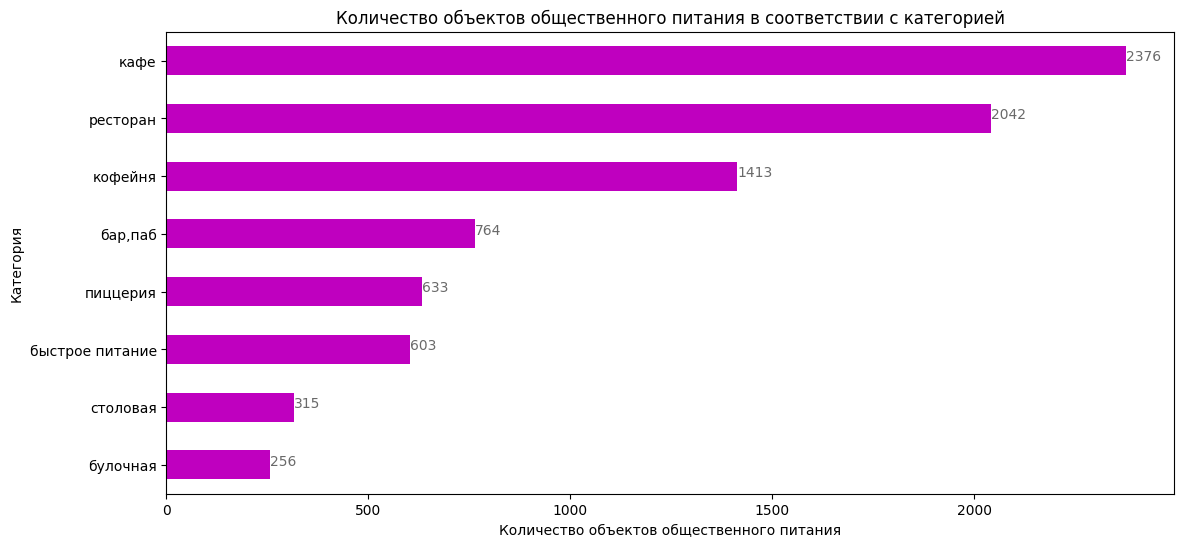

In [18]:
df['category'].value_counts(ascending=True).plot(kind='barh',
                                   y = 'category',
                                   color = 'm',
                                   figsize = (13, 6))
for i, v in enumerate(df['category'].value_counts(ascending=True)):
    plt.text(v + 1, i, str(v), color='dimgray') #добавляем подпись с количеством значений
    
plt.title('Количество объектов общественного питания в соответствии с категорией')
plt.ylabel('Категория')
plt.xlabel('Количество объектов общественного питания')
plt.show()

Кафе - самая популярная категория из всех заведений (2376 шт). Топ с ней разделяют ресторан (2042 шт.) и кофейня (1413 шт.).

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

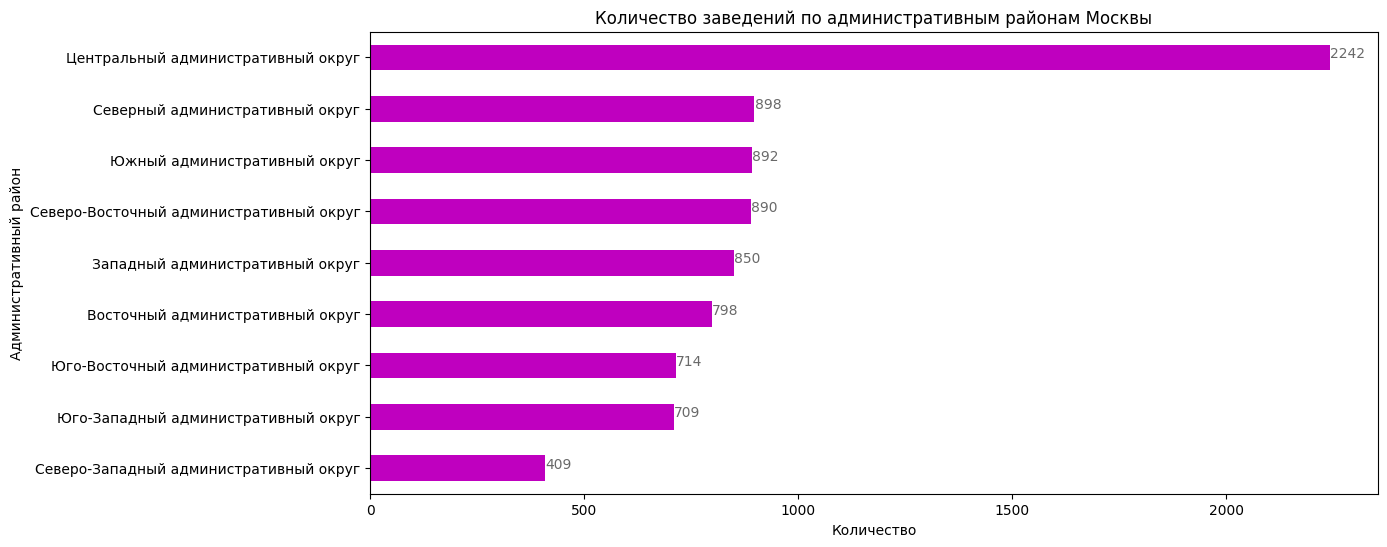

In [19]:
df['district'].value_counts(ascending=True).plot(kind='barh',
                                                 y = 'district',
                                                 color = 'm',
                                                 figsize = (13, 6)
                                                )
for i, v in enumerate(df['district'].value_counts(ascending=True)):
    plt.text(v + 1, i, str(v), color='dimgray') #добавляем подпись с количеством значений
plt.ylabel('Административный район')
plt.xlabel('Количество')
plt.title('Количество заведений по административным районам Москвы')
plt.show()

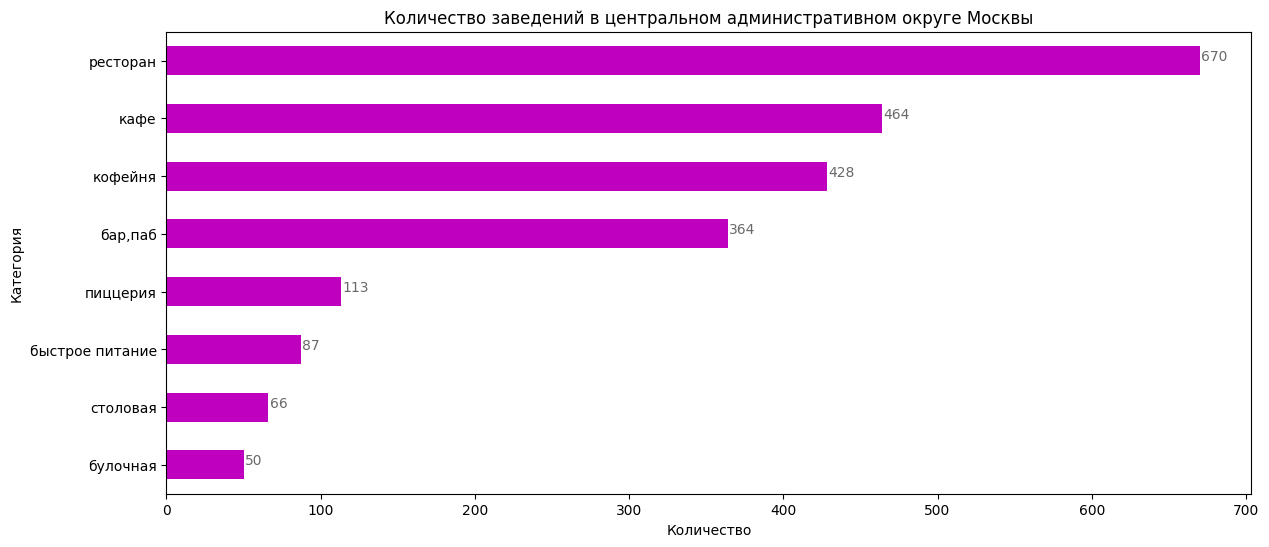

In [20]:
df_centr = df[df['district']=='Центральный административный округ']
df_centr['category'].value_counts(ascending=True).plot(kind='barh',
                                                 y = 'category',
                                                 color = 'm',
                                                 figsize = (14, 6)
                                                )
for i, v in enumerate(df_centr['category'].value_counts(ascending=True)):
    plt.text(v + 1, i, str(v), color='dimgray') #добавляем подпись с количеством значений
plt.ylabel('Категория')
plt.xlabel('Количество')
plt.title('Количество заведений в центральном административном округе Москвы')
plt.show()

В центральном районе Москвы сосредоточено больше всего заведений (2242 шт). Непопулярным округом для размещения общепита является северо-западный (409 шт).

Также отдельно мы визуализировали распределение заведений каждой категории в Центральном административном округе Москвы. Здесь мы наблюдаем немного другую картину, нежели в первом задании. Самым популярным заведением является ресторан (670 шт), а после него уже кафе (464 шт) и кофейня (428 шт)

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

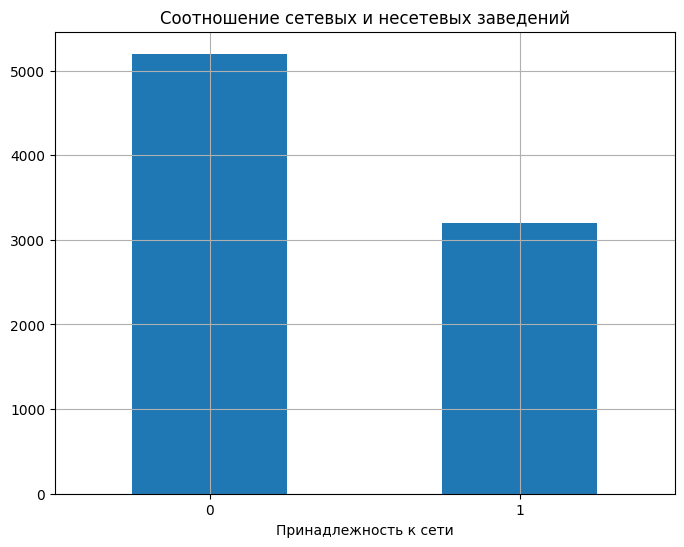

In [21]:
df['chain'].value_counts().plot(kind='bar', 
                                x = 'chain',
                                rot = 0,
                                figsize = (8, 6))
plt.grid()
plt.title('Соотношение сетевых и несетевых заведений')
plt.xlabel('Принадлежность к сети')
plt.show()

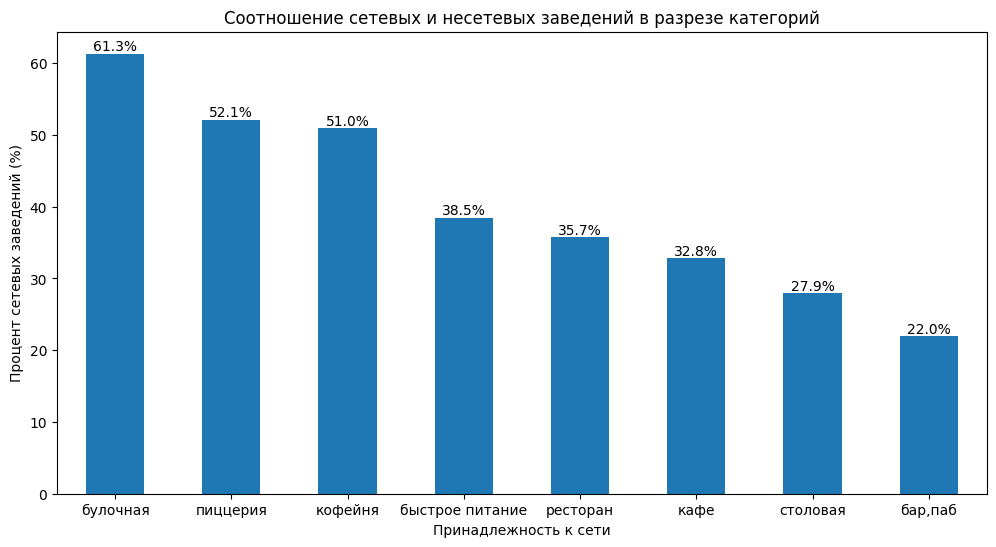

In [22]:
setev_ax = df[df['chain'] == 1]
full_ax = df.groupby('category')['chain'].value_counts().unstack(fill_value=0).sum(axis=1)
# группируем только сетевые заведения
setev_ax = setev_ax.groupby('category')['chain'].value_counts().unstack(fill_value=0)
ax = (setev_ax.sum(axis=1)/full_ax) * 100
ax = ax.sort_values(ascending=False)

ax.plot(kind='bar', rot = 0,figsize = (12, 6))

# Получаем значения высот столбцов
heights = ax.values

# Добавляем подписи через enumerate
for i, v in enumerate(heights):
    plt.text(
        x=i,  # позиция по оси X
        y=v,  # позиция по оси Y
        s=f'{v:.1f}%',  # текст с процентами
        ha='center',  # выравнивание по горизонтали
        va='bottom',  # выравнивание по вертикали
        fontsize=10,  # размер шрифта
        color='black'  # цвет текста
    )

plt.title('Соотношение сетевых и несетевых заведений в разрезе категорий')
plt.xlabel('Принадлежность к сети')
plt.ylabel('Процент сетевых заведений (%)')
plt.show()

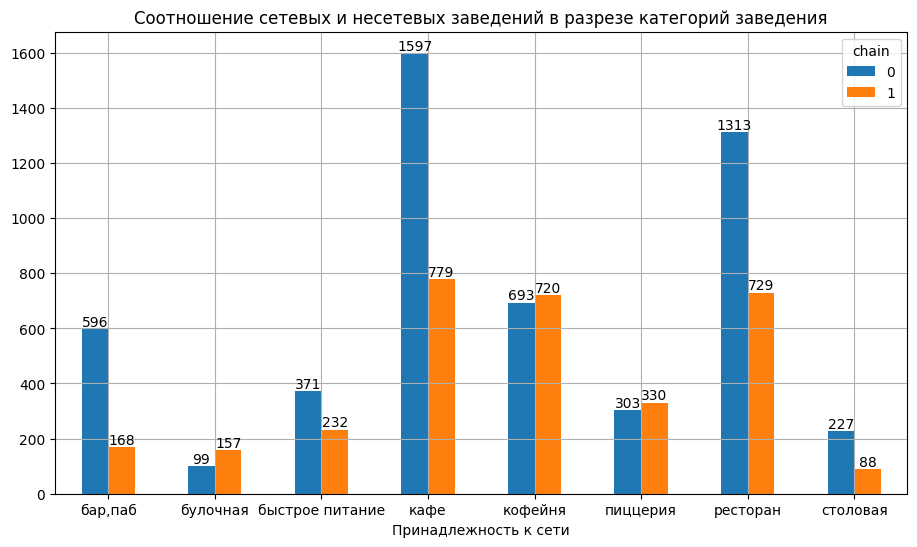

In [23]:
ax = df.groupby('category')['chain'].value_counts().unstack(fill_value=0).plot(kind='bar', rot = 0,figsize = (11, 6))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width/2, 
            y + height, 
            f'{int(height)}', 
            ha='center', 
            va='bottom')
plt.grid()
plt.title('Соотношение сетевых и несетевых заведений в разрезе категорий заведения')
plt.xlabel('Принадлежность к сети')
plt.show()

Исходя их построенных графиков, мы видим, что несетевых заведений больше как минимум в полтора раза. Больше всего их приходится на `кафе` (1597 шт.) и `рестораны` (1313 шт.). `Столовые` имеют меньше всего сетей (88 шт).

Топ 3 по соотношению сетевых и несетевых заведений занимают `булочные` (61.3%), `пиццерии` (52.1%) и `кофейни` (51%). `Бары/пабы` занимают последнее место с 22%.

Для выбора подходящей категории с небольшой конкуренцией необходимо провести дополнительный анализ (в задаче 7 мы это сделаем)

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [24]:
df['seats'].describe() # первое знакомство

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

In [25]:
# вычисляем квартили Q1 и Q3
Q1 = df.groupby('category')['seats'].quantile(0.25)
Q3 = df.groupby('category')['seats'].quantile(0.75)

# вычисляем межквартильный размах IQR
IQR = Q3 - Q1


In [26]:
# вычисляем медиану
median = df.groupby('category')['seats'].quantile(0.5)
# создаем сводную таблицу
summary_stats = pd.DataFrame({
    'Медиана': median,
    'IQR': IQR
})
summary_stats.sort_values(by='Медиана', ascending=False)

,Медиана,IQR
category,,
ресторан,86.0,102.0
"бар,паб",82.0,100.5
кофейня,80.0,104.0
столовая,75.5,77.0
быстрое питание,65.0,112.0
кафе,60.0,85.0
пиццерия,55.0,90.0
булочная,50.0,95.0


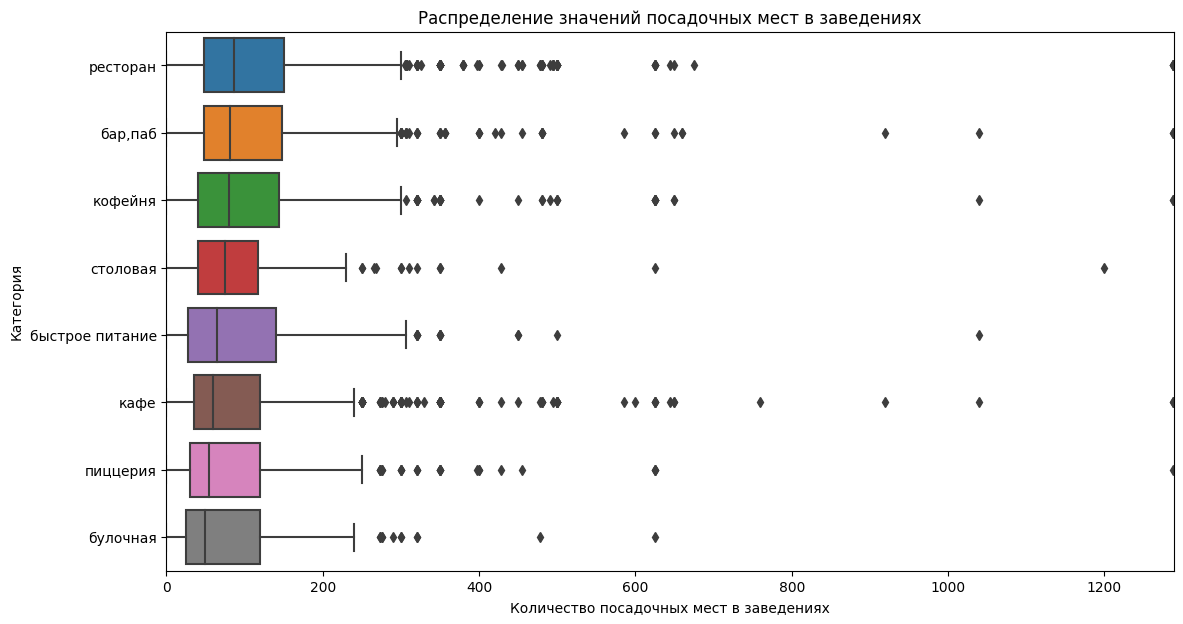

In [27]:
plt.figure(figsize=(13, 7))

sns.boxplot(data=df, x='seats', y='category', order=median.sort_values(ascending=False).index)

plt.title('Распределение значений посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест в заведениях')
plt.ylabel('Категория')
plt.xlim(0, 1289)

plt.show() 

В начале мы получили краткое статистическое описание данных столбца `seats`. Максимальное количество посадочных мест - 1288 шт. Явно аномальное значение.

Построив "ящик с усами" по категориям, чётко виднеются выбросы в каждой категории. Это может быть связано с разными причинами:
- ошибка при сборе информации;
- опечатка;
- проблема в системе базы данных;
- индивидуальность заведения (возможно, владелец какого-либо общепита решил таким образом выделиться);
- уникальность франшизы и тд.

Выводы по каждой категории:

1. **рестораны, бары/пабы** и **кофейни** лидируют по количеству посадочных мест (медиана 86, 82 и 80 соответственно). Межквартальный размах у них большой (102, 100.5 и 104), что может говорить о разнообразии заведений этих категорий
2. **столовая** имеет медиану 75 посадочных мест. Размах у этой категории небольшой - IQR равен 77 . Это говорит о том, что владельцы придерживаются оптимального количества мест.
3. медиана категории **быстрое питание** составляет 65 мест. Размах тут самый большой - IQR равен 112. Скорее всего, количество посадочных мест зависит от проходимости и популярности заведения.
4. в категории **кафе** медиана равняется 60. Размах умеренный -  IQR равен 85.
5. **пиццерия** имеет значительный размах - 90 мест, хотя медиана составляет 55 мест. Скорее всего существуют популярные заведения данной категории с хорошей проходимостью, где есть необходимость иметь большое количество посадочных мест. Однако для более чёткого ответа необходимо провести дополнительный анализ
6. **булочные** имеют наименьшее количество посадочных мест - медиана равняется  50, но достаточно большой размах - 95 мест. Это указывает на различные возможности и цели заведений данной категории.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

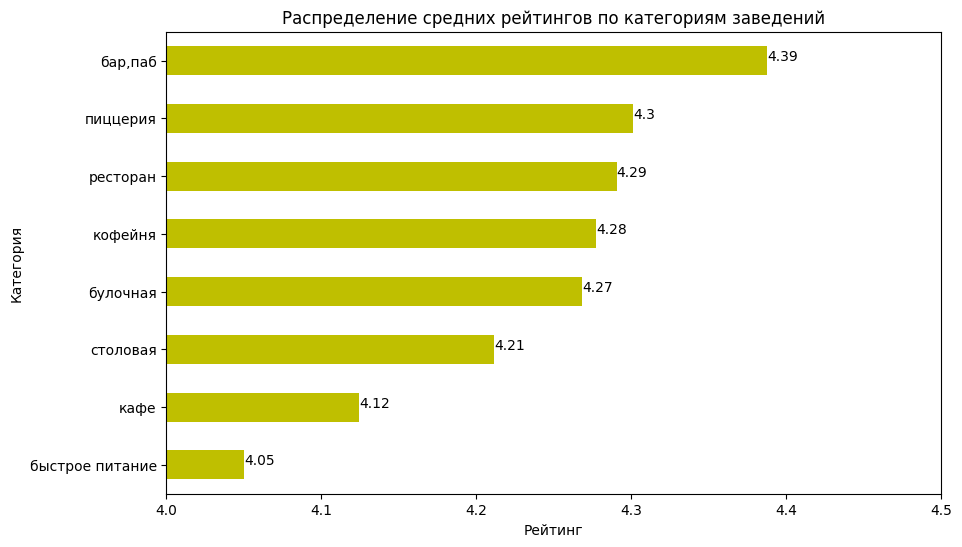

In [28]:
rating_category = df.groupby('category')['rating'].mean()
rating_category.sort_values().plot(kind = 'barh',
                                   color = 'y',
                                   figsize = (10, 6))
for i, v in enumerate(rating_category.sort_values()):
    plt.text(v, i, str(round(v, 2)))

plt.ylabel('Категория')
plt.xlabel('Рейтинг')
plt.title('Распределение средних рейтингов по категориям заведений')
plt.xlim(4, 4.5)
plt.show()

С хорошим отрывом среди всех категорий **бар/паб** занимает первое место со средним рейтингом  - 4.39. На мой взгляд, приятные цены на алкоголь и закуски, создание лёгкой и уютной атмосферы (ещё есть заведения с различной тематикой, в которые любят ходить определённые клиенты), быстрое обслуживание, наличие развлекательных игр или программ стимулируют выставление высокой оценки заведению.

**Пиццерия**(4.3), **рестораны** (4.29), **кофейни**(4.28) и **булочные имеют**(4.27) имеют более-менее одинаковый рейтинг. Размах составляет 0.03

С категорией **быстрое питание** всё иначе. Словосочетание говорит само за себя. Владельцам не выгодно, чтобы клиент у них задерживался. Здесь роль играет скорость, а не уют и атмосфера. Никто не пытается угодить клиентам. Цель: пропустить как можно больше людей с минимальными издержками. Поэтому продукты, чистота помещения и иногда неоправдано завышенные цены вызывают негативные эмоции у посетителей 

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

interval columns not set, guessing: ['rating', 'category_corr', 'district_corr', 'chain', 'seats', 'price_corr', 'middle_avg_bill', 'middle_coffee_cup']


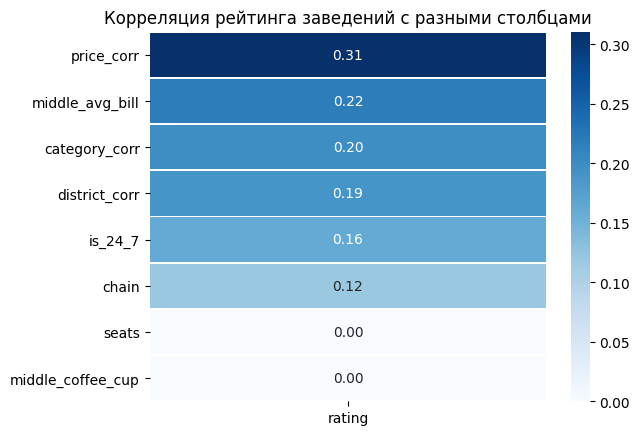

In [29]:
# укажем каждому уникальному значению в столбцах уникальный номер для подсчета корреляции
df['category_corr'] = df['category'].factorize()[0] 
df['district_corr'] = df['district'].factorize()[0]
df['price_corr'] = df['price'].factorize()[0]
df_stolbs = ['rating', 'category_corr', 'district_corr', 'chain', 'seats', 'price_corr', 'middle_avg_bill', 'middle_coffee_cup', 'is_24_7']

# Вычисляем phik корреляцию
corre = df[df_stolbs].phik_matrix()

# Выбираем корреляцию только с рейтингом
rating_corr = corre[['rating']].drop('rating', axis=0).sort_values(by='rating', ascending=False)

sns.heatmap(
    data=rating_corr,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Корреляция рейтинга заведений с разными столбцами')
plt.show()

In [30]:
df.groupby('price')['rating'].mean().sort_values(ascending=False)

price
высокие          4.436611
выше среднего    4.386348
средние          4.297874
низкие           4.173077
Name: rating, dtype: float32

In [31]:
df.groupby(['middle_avg_bill', 'price'])['rating'].mean().sort_values(ascending=False)

middle_avg_bill  price        
1650.0           высокие          4.900000
7250.0           высокие          4.900000
284.0            средние          4.800000
6500.0           высокие          4.800000
825.0            средние          4.750000
                                    ...   
200.0            низкие           3.733333
140.0            низкие           3.600000
1000.0           выше среднего    3.550000
4500.0           высокие          3.533333
240.0            низкие           3.500000
Name: rating, Length: 212, dtype: float32

In [32]:
df.groupby('district')['rating'].mean().sort_values(ascending=False)

district
Центральный административный округ         4.377520
Северный административный округ            4.240980
Северо-Западный административный округ     4.208802
Южный административный округ               4.184417
Западный административный округ            4.181647
Восточный административный округ           4.174185
Юго-Западный административный округ        4.172920
Северо-Восточный административный округ    4.147977
Юго-Восточный административный округ       4.101120
Name: rating, dtype: float32

In [33]:
df.groupby('seats')['rating'].mean().sort_values(ascending=False)

seats
760.0    4.900000
29.0     4.900000
13.0     4.900000
245.0    4.800000
286.0    4.700000
           ...   
228.0    3.533333
147.0    3.500000
41.0     3.418182
114.0    3.066667
81.0     2.900000
Name: rating, Length: 229, dtype: float32

 ---

Проверив матрицу корреляции рейтинга заведений с разными данными, можно сказать следующее:
1. Имеется положительная записимость со столбцом `price` (0.31). Следовательно, чем выше цена, тем выше рейтинг. Как правило, в подобных заведениях интерьер, сервис и еда на высшем уровне, что соответствует прайсу. Клиенты понимают, за что платят;
2. На втором месте расположился столбец `middle_avg_bill` (0.22) с оценкой среднего чека. Он явно связан с прайсом;
3. Никакой связи со столбцами `seats` и `middle_coffee_cup`. Как цена на капучино никак не влияет на рейтинг, так и количество мест.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

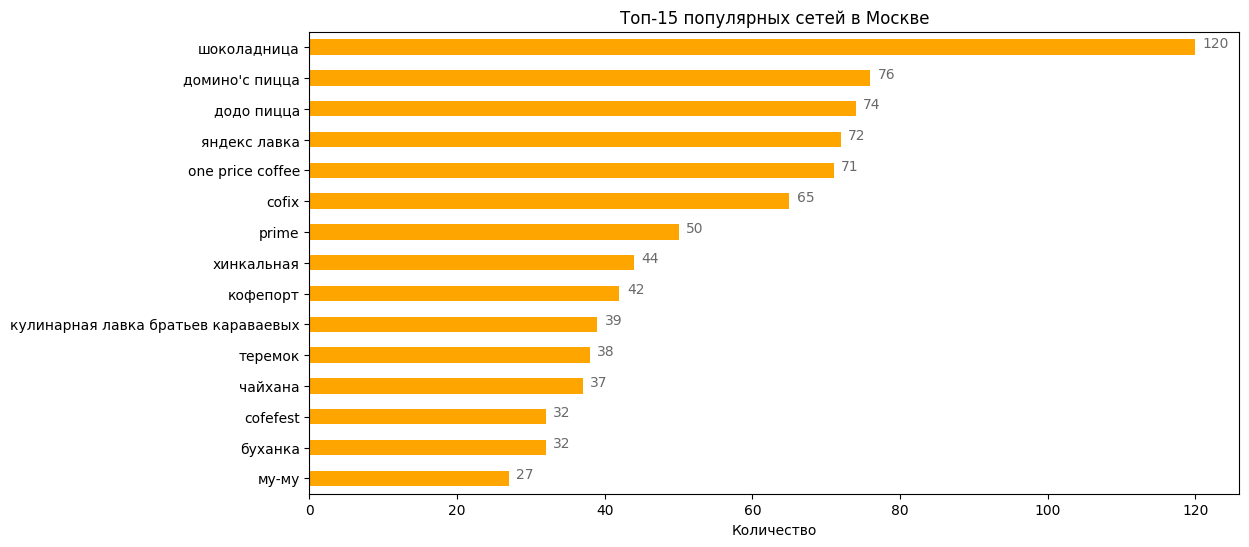

In [34]:
df_p = df[df['chain'] == 1]
name_popular = df_p['name'].value_counts(ascending=False).head(15).sort_values()
name_popular.plot(kind='barh', color='#FFA500', figsize = (12, 6))

for i, v in enumerate(name_popular.sort_values()):
    plt.text(v + 1, i, str(v), color='dimgray')
plt.xlabel('Количество')
plt.title('Топ-15 популярных сетей в Москве')
plt.show()

In [35]:
# Получаем список популярных названий
popular_names = name_popular.index
df_p = df_p[df_p['name'].isin(popular_names)]

# Находим наиболее частую категорию
name_category = df_p.groupby('name')['category'].apply(lambda x: x.mode()[0])
# Создаем словарь для map
category_mapping = name_category.to_dict()


df_p['category'] = df_p['name'].map(category_mapping)

name_rating = pd.pivot_table(
    df_p, 
    index = ['name', 'category'],
    values = 'rating',
    aggfunc = 'mean')
name_rating.sort_values(by='rating', ascending=False)

,,rating
name,category,
буханка,булочная,4.396875
кулинарная лавка братьев караваевых,кафе,4.394872
хинкальная,кафе,4.322727
додо пицца,пиццерия,4.286487
му-му,кафе,4.229630
шоколадница,кофейня,4.177500
домино'с пицца,пиццерия,4.169737
кофепорт,кофейня,4.147619
теремок,ресторан,4.123684


---

Опираясь на представленную визуализацию, можно сказать следующее:
1. Больше всего заведений по городу Москва имеет сеть `"Шоколадница"` (120 шт). Она относится к категории "кофейня". Рейтинг у неё хороший, но не самый лучший из представленных выше сетей (4.18). 
2. На 2-ом и 3-ем местах по количеству сетей расположилась категория "пиццерия" - заведения `"Домино'с пицца"`(76 шт) с рейтингом (4.17) и `"Додо пицца"`(74 шт) с рейтингом (4.29).
3. Замыкают топ с количеством сетей заведения `"Буханка"` (32 шт) и `"Му-му"` (27 шт). У первого самый высокий рейтинг из представленных - 4.4. Что интересно, это единственная булочная в списке. 
Заведение `"Му-му"` входит в категорию "кафе" и также имеет неплохой рейтинг - 4.23
4. Кафе `"Чайхана"` и ресторан `"Яндекс лавка"` занимают последние позиции в таблице с рейтингом (3.92 и 3.86 соответственно). Причиной такого результата может быть как сервис, так и еда
    
    Мы имеем в топе 5 кофеен, 4 кафе, 3 ресторана, 2 пиццерии и 1 булочную. 
    
    Выпечка хорошо себя зарекомендовала. Хорошее качество и сервис выводят заведение `"Буханка"` в топ рейтинга даже с небольшим количеством точек в столице.
    
    Заходить за вкусным кофе любят многие, поэтому владельцы популярных сетей не стоят на месте и стараются расширять свой бизнес. Однако им стоит поработать над сервисом и качеством своих товаров, чтобы поднимать рейтинг

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


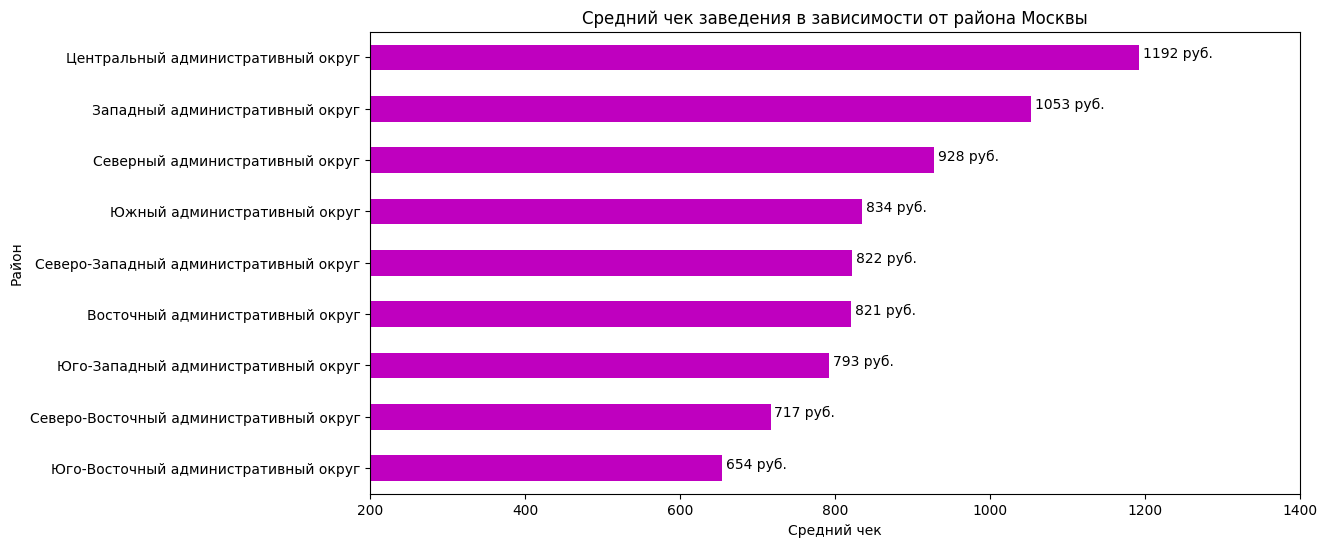

In [36]:
df_clean = df[df['middle_avg_bill'] > 0]
avg_bill = df_clean.groupby('district')['middle_avg_bill'].mean().sort_values()
avg_bill.plot(kind='barh', color = 'm', figsize = (12, 6))

for i, v in enumerate(avg_bill):
    plt.text(v + 5, i, f"{round(v)} руб.") #добавляем подпись 
plt.ylabel('Район')
plt.xlabel('Средний чек')
plt.title('Средний чек заведения в зависимости от района Москвы')
plt.xlim(200, 1400)
plt.show()


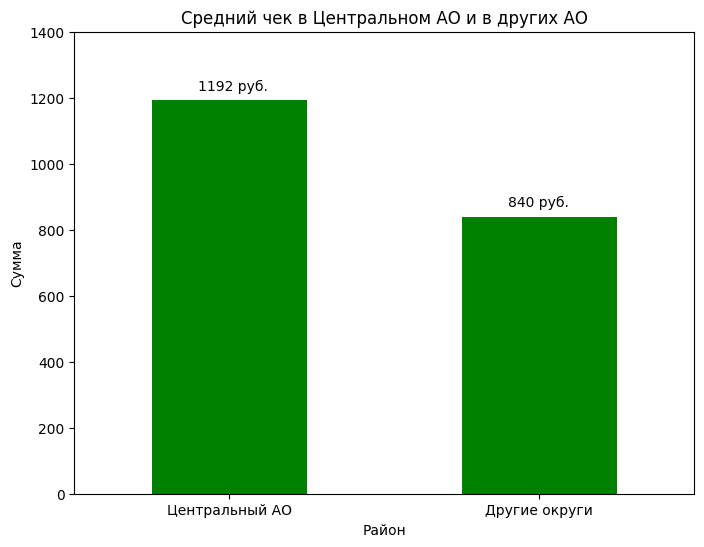

In [37]:
center_district = df_clean[(df_clean['district'] == 'Центральный административный округ')] # ищем центральный АО 
avg_center = center_district['middle_avg_bill'].mean() #
notcenter_district = df_clean[(df_clean['district'] != 'Центральный административный округ')] #
avg_notcenter = notcenter_district['middle_avg_bill'].mean() #

# Создаём датафрейм для визуализации
avg_data = pd.DataFrame({
    'Район': ['Центральный АО', 'Другие округи'],
    'Средний чек': [avg_center, avg_notcenter]
})

avg_data.plot(kind='bar', x = 'Район', legend = False, rot = 0, figsize=(8,6), color='g')

for i, v in enumerate(avg_data['Средний чек']):
    plt.text(i-0.1, v+30, f"{round(v)} руб.")
plt.title('Средний чек в Центральном АО и в других АО')
plt.ylabel('Сумма')
plt.ylim(0, 1400) 
plt.show()

In [38]:
difference = avg_center - avg_notcenter
print(f'Разница среднего чека между Центральным АО и другими составляет: {round(difference)} руб.')
print(f'В Центральном районе средняя цена чека выше на {round((avg_center/avg_notcenter-1)* 100, 2)}%')

Разница среднего чека между Центральным АО и другими составляет: 352 руб.
В Центральном районе средняя цена чека выше на 41.96%


---

Благодаря визуализации, мы видим, что разница среднего чека между `Центральным районом` и `другими` составляет 352 руб, что на 42% выше, чем в других округах. `Западный АО` расположился после центра, на втором месте, со средней стоимостью заказа 1053 руб.

`Северо-Восточный АО` и `Юго-Восточный АО` имеют самый низкий средний чек (717 руб. и 654 руб. соответсвенно)

Можно сказать, что существует прямая корреляция между округом и средним чеком в заведениях. Районы с высокой деловой активностью привлекают более дорогие форматы заведений. Округа Москвы с меньшей плотностью бизнес-компаний располагают более демократичными ценами в заведениях общественного питания

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

После проведения исследовательского анализа данных можно сделать следующие выводы:

- `Кафе` — самая популярная категория из всех заведений (2376 шт). Топ с ней разделяют `рестораны` (2042 шт.) и `кофейни` (1413 шт.);
- В Центральном районе Москвы сосредоточено больше всего заведений (2242 шт). Цена среднего чека на 42% выше, чем в других округах. Самой популярной категорией является `ресторан` (670 шт);
- Несетевых заведений больше как минимум в полтора раза. Много приходится на кафе (1597 шт.) и рестораны (1313 шт.). Подавляющее число сетевых заведений имеется в таких категориях, как `булочная` (61.3%), `пиццерия` (52.1%) и `кофейня` (51%);
- `рестораны` и `бары/пабы` имеют наибольшее количество посадочных мест (медиана 86 и 82 соответственно). `Булочные` - наоборот (медиана равняется 50);
- Больше всего заведений по городу Москва имеет сеть "Шоколадница" (120 шт);
- Категория `бар/паб` занимает первое место со средним рейтингом 4.39;
- На первом месте в топ-15 по количеству сетей в городе Москва находится "Шоколадница" (120 шт). На предпоследнем месте - заведение "Буханка" (32 шт), которое относится к категории булочная. Однако у него имеется самый высокий рейтинг из всех представленных в топе — 4.4;
- Существует положительная корреляция между ценой и рейтингом;
- Часы работы или количество сетей у какого-либо заведения не оказывают никакого влияния на рейинг.

## 4. Итоговый вывод и рекомендации


**Для корректного проведения исследовательского анализа и составлений рекомендаций было сделано следующее:**
- соеднинили датасеты, в которых содержится информация о среднем чеке и заведениях;
- для столбцов `chain` и `rating` был подобран оптимальный тип данных с подходящей разрядностью;
- избавились от неявных дубликатов в столбце с названием заведения — 103 (количество уникальных значений поменялось с 5614 шт на 5511 шт) и с адресом заведения — 1 (количество уникальных значений поменялось с 5753 шт на 5752 шт). В итоге удалили 4 полных дубликатов (0.05% от общего числа);
- создали столбец `is_24_7` с обозначением того, является ли заведение круглосуточным и работает ли ежедневно.

**Отвечая на исследовательские вопросы, были сформированы следующие выводы:**
- ***кафе*** — самая популярная категория из всех заведений (2376 шт). Больше половины приходится на несетевые (1597 шт). Данная категория имеет практически самый низкий рейтинг (4.12);
- ***рестораны*** входят в топ по количеству заведений (2042 шт.). Они имеют наибольшее количество посадочных мест (медиана составляет 86 шт), хороший рейтинг и занимают второе место по количеству несетевых заведений (1313 шт). Для Центрального административного округа Москвы рестораны — самая  популярная категория (670 шт);
- ***кофейни*** представлены крупными сетями (720 против 693 несетевых) и имеют хорошую вместимость (в среднем 80 мест). Рейтинг средний — 4.28;
- ***бары/пабы*** имеют наивысший рейтинг среди всех категорий (4.39). Медиана посадочных мест — 82. Несетевых заведений больше (596 против 168 сетевых);
- количество сетевых заведений в категории ***пиццерия*** больше, нежели несетевых (330 шт. против 303 шт.) Занимают второе место рейтинга На 2-ом и 3-ем местах по количеству точек в Москве как раз-таки заведения "Домино'с пицца"(76 шт) с рейтингом (4.17) и "Додо пицца"(74 шт) с рейтингом (4.29). В целом, данную категорию люди любят и ставят высокую ценку в Яндекс Картах (4.3);
- ***столовые*** имеют оптимизированную модель бизнеса: не самый плохой уровень рейтинга, владельцы придерживаются оптимального количества посадочных мест и их не так много (315 шт);
- ***быстрое питание*** имеет самый низкий рейтинг (4.05). Количество посадочных мест в среднем 65, фокус на скорости обслуживания, за клиентов борьбы нет;
- ***булочные*** — хороший пример успешной специализации. Средний рейтинг (4.27), небольшое количество посадочных мест (медиана 50), стабильно высокий спрос. Пример — сеть «Буханка». Количество точек небольшое — 32 шт, а рейтинг самый высокий среди сетевиков — 4.4.

### Рекомендации:

Инвесторы из фонда Shut Up and Take My Money должны ориентироваться на свои возможности при выборе категории для открытия заведения. Беспроигрышный вариант это **булочная** или **бары/пабы**. Они показывают хорошую статистику и небольшую конкуренцию. 

После успешного запуска **бара/паба** можно пойти на расширение и открывать другие точки, так как крупных сетевиков практически нет. Необходимо ориентироваться на уникальность, на интересное оформление интерьера. Разработка широкого и интересного меню с хорошими коктейлями и закусками тоже обязательный фактор. Если всё сделать правильно, можно выйти в топ по всем параметрам.

Если хочется немного сэкономить и остаться в выигрышном положении, то **булочная** это идеальный вариант. Важный принцип - высокое качество. Выпечка должна быть такая, за которой хочется возвращаться. Здесь имеется один крупный сетевик "Буханка". Он показывает, что не обязательно вкладывать большие деньги для открытия бизнеса. Можно иметь хорошую репутацию, продавая лишь вкусную еду и хороший сервис.
